[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T08_A_labor_flows_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Tema 8 — Búsqueda Laboral, Flujos de Trabajadores y Dinámica del Desempleo

En los modelos macroeconómicos sin fricciones, el mercado laboral se vacía de forma continua: el salario real se ajusta instantáneamente para igualar la oferta y la demanda de trabajo, eliminando cualquier posibilidad de desempleo involuntario. En la realidad empírica, los mercados de trabajo se caracterizan por profundas fricciones de búsqueda y emparejamiento. La creación de una relación laboral productiva exige cuantiosas inversiones de tiempo y recursos tanto por parte de los trabajadores que buscan empleo como de las empresas que reclutan vacantes. En consecuencia, el desempleo no es una masa estática de mano de obra inactiva, sino un stock de equilibrio gobernado por flujos dinámicos continuos.

La teoría moderna del desempleo de equilibrio se fundamenta en el marco de búsqueda y emparejamiento de **Diamond-Mortensen-Pissarides (DMP)**. En este tema, analizamos las fluctuaciones del mercado laboral a través de los flujos de trabajadores y las fricciones de búsqueda:

1. **Dinámica de Bañera y Flujos Brutos**: Modelizamos la evolución del desempleo como un sistema dinámico de stocks y flujos, y estimamos las probabilidades mensuales de transición —la tasa de encuentro de empleo ($f$) y la tasa de separación ($s$)— a partir de los flujos brutos de la Current Population Survey (CPS) siguiendo a **Shimer (2005, 2012)**.
2. **Descomposición entre Margen de Oferta y Demanda**: Descomponemos los cambios en el empleo agregado entre márgenes de participación laboral (transiciones que cruzan la frontera de inactividad) y márgenes de emparejamiento (reasignación entre empleo y desempleo).
3. **El Sector Informal como Amortiguador de Ajuste**: A partir de los microdatos trimestrales de la Encuesta Nacional de Ocupación y Empleo (ENOE) de México, examinamos cómo el empleo informal opera como un seguro de desempleo informal de facto, transformando la transmisión macroeconómica de los shocks agregados.
4. **Márgenes Intensivo y Extensivo**: Mediante el panel armonizado de la OCDE en 38 países, contrastamos el ajuste del factor trabajo entre personas empleadas (cabezas) y horas trabajadas durante crisis macroeconómicas severas como el shock del COVID-19.
5. **Teoría DMP y la Curva de Beveridge**: Formalizamos la función de emparejamiento agregada $M(U, V)$, derivamos la curva de Beveridge de equilibrio e inspeccionamos la negociación salarial de Nash.
6. **Experimento Empírico — El Enigma de Volatilidad de Shimer (2005)**: Evaluamos la crítica fundamental al modelo DMP estándar, demostrando por qué los salarios flexibles de Nash asfixian la volatilidad de las vacantes, y examinamos las resoluciones propuestas por la calibración de "excedente pequeño" de **Hagedorn-Manovskii (2008)** y la rigidez del salario real de **Hall (2005)**.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))
if str(_nb / "course") not in sys.path:
    sys.path.insert(0, str(_nb / "course"))

import _nbstyle
_nbstyle.apply_style()

## 1. Dinámica del Desempleo y Flujos Brutos de Trabajadores

El desempleo es un stock dinámico alimentado por las separaciones laborales y vaciado por las contrataciones exitosas. En tiempo continuo, la tasa de desempleo $u_t$ evoluciona según la ecuación diferencial fundamental de entradas y salidas:

$$\dot{u}_t = s_t (1 - u_t) - f_t u_t$$

donde $s_t$ denota la **tasa de separación** (la tasa a la que los trabajadores empleados pierden o dejan sus puestos) y $f_t$ denota la **tasa de encuentro de empleo** (*job-finding rate*, la tasa a la que los desempleados consiguen un puesto de trabajo). En el estado estacionario ($\dot{u}_t = 0$), la tasa de desempleo converge a la clásica **ecuación de bañera**:

$$u^* = \frac{s}{s + f}$$

En Estados Unidos, la Oficina de Estadísticas Laborales (BLS) mide estas transiciones mediante la Current Population Survey (CPS). Debido a que los hogares son encuestados en meses consecutivos, el BLS elabora series mensuales de **flujos brutos** entre los tres estados canónicos del mercado laboral:
- **Empleo ($E$)**
- **Desempleo ($U$)**
- **Inactividad / Fuera de la Fuerza Laboral ($N$)**

Mediante `puremacro.labor_flows.transitions_from_cps_flows`, dividimos el conteo de flujos brutos mensuales por el stock rezagado de origen para construir matrices estocásticas de transición y analizar el comportamiento cíclico de $f$ y $s$.

In [3]:
from pathlib import Path

from puremacro.labor_flows import transitions_from_cps_flows

# Flujos brutos de la CPS (BLS, miles de personas, desestacionalizados) y stocks
# E/U/N, congelados en data_curso/ para que el cuaderno corra sin red.
CPS_FLOWS = {"EE": "LNS17000000", "EU": "LNS17400000", "EN": "LNS17800000",
             "UE": "LNS17100000", "UU": "LNS17500000", "UN": "LNS17900000",
             "NE": "LNS17200000", "NU": "LNS17600000"}
CPS_STOCKS = {"E": "CE16OV", "U": "UNEMPLOY", "N": "LNS15000000"}

from _datos import DATOS, ruta_dato, _safe_probe

DATA = DATOS if _safe_probe(ruta_dato("LNS17000000.csv"), is_dir=False) else None

def _fred_series(sid):
    df = pd.read_csv(ruta_dato(f"{sid}.csv"), parse_dates=["observation_date"])
    return df.set_index("observation_date")[sid].astype(float)

panel = None
if DATA is None:
    print("No encuentro los datos congelados del curso (data_curso/).")
    print("Copia esa carpeta junto a notebooks/ y vuelve a ejecutar esta celda.")
else:
    flows = pd.DataFrame({k: _fred_series(v) for k, v in CPS_FLOWS.items()})
    stocks = pd.DataFrame({k: _fred_series(v) for k, v in CPS_STOCKS.items()}).dropna()
    # El BLS no publica el flujo N->N: se despeja por residuo del stock rezagado
    # de no-participantes.
    flows["NN"] = stocks["N"].shift(1) - flows["NE"] - flows["NU"]
    panel = transitions_from_cps_flows(flows.dropna(), stocks)

    # p_UE: probabilidad de pasar de desempleo a empleo (tasa de encuentro de empleo, f).
    # p_EU: probabilidad de pasar de empleo a desempleo (tasa de separación, s).
    monthly = panel.monthly.loc["2000":]
    f_avg, s_avg = monthly["p_UE"].mean(), monthly["p_EU"].mean()
    print(f"CPS, medias mensuales de {monthly.index[0]:%Y-%m} a {monthly.index[-1]:%Y-%m}:")
    print(f"  Tasa de encuentro de empleo (f = p_UE): {f_avg:.3f}")
    print(f"  Tasa de separación          (s = p_EU): {s_avg:.4f}")
    print(f"  Desempleo de estado estacionario u* = s/(s+f): {s_avg / (s_avg + f_avg):.2%}")

CPS, medias mensuales de 2000-01 a 2026-06:
  Tasa de encuentro de empleo (f = p_UE): 0.248
  Tasa de separación          (s = p_EU): 0.0130
  Desempleo de estado estacionario u* = s/(s+f): 4.96%


### Anatomía Cíclica de las Transiciones Laborales: Contratación vs. Despido

El análisis empírico de los flujos de la CPS revela una asimetría esencial a lo largo del ciclo económico:
- La **tasa de encuentro de empleo ($f = p_{UE}$)** es intensamente **procíclica**: durante las recesiones, la contratación se desploma y la probabilidad de salir del desempleo cae abruptamente. Durante la Gran Recesión (2007–2009), la tasa mensual de encuentro cayó, en media móvil de doce meses, de 0.283 a 0.173 —un colapso del 39%—, lo que prolongó significativamente la duración media del desempleo ($1/f$).
- La **tasa de separación ($s = p_{EU}$)** es **contracíclica**: los despidos repuntan con fuerza al comienzo de las recesiones (subiendo de 0.0122 a 0.0183 durante la Gran Recesión, en la misma media móvil).

Como enfatiza **Shimer (2005, 2012)**, en los ciclos económicos anglosajones estándar, las fluctuaciones en la tasa de contratación ($f$) explican aproximadamente tres cuartas partes de la volatilidad cíclica del desempleo, mientras que los picos de separación son intensos pero efímeros. El shock del COVID-19 en 2020 representó una excepción inédita: las suspensiones temporales hicieron que $s$ se disparara violentamente hasta 0.112 en abril de 2020 —más de diez veces su nivel de enero—, pero la expectativa de reincorporación rápida mantuvo las tasas de encuentro relativamente estables.

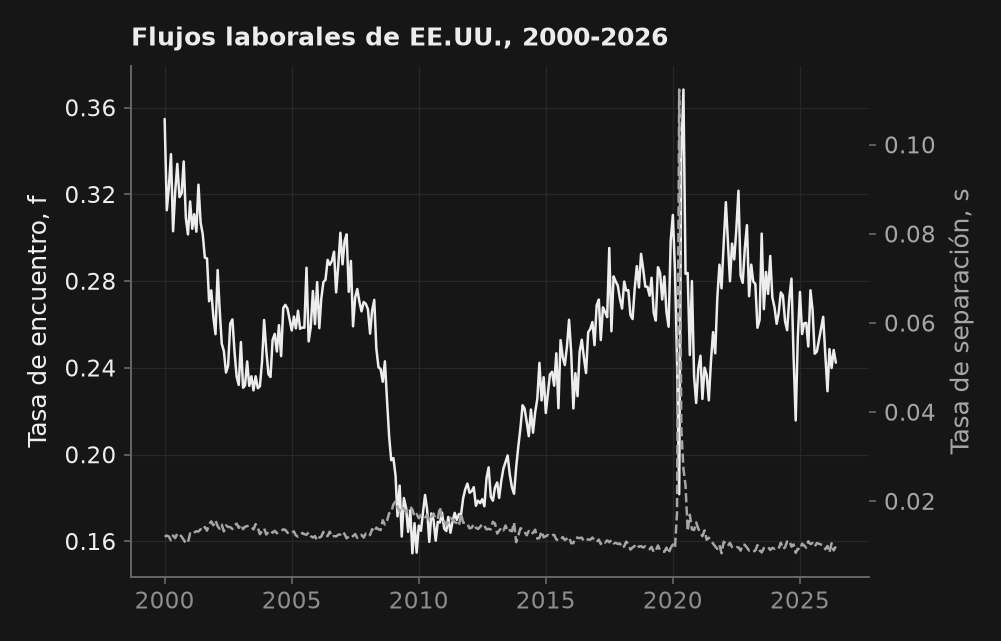

In [4]:
if panel is None:
    print("Sin los datos de data_curso/ no hay serie que graficar (ver la celda anterior).")
else:
    import matplotlib.dates as mdates

    # La celda hereda el tamaño que le fija el arnés: el del cuaderno al
    # ejecutarla, el de la ranura de la lámina al exportarla. Construida ya a
    # su tamaño final, el trazo, los años y los rótulos se eligen para ese ancho.
    tam = plt.rcParams["figure.figsize"]
    estrecho = tam[0] < 4.0
    fig, ax1 = _nbstyle.figura(figsize=tam)
    lw = 0.8 if estrecho else 1.2

    ax1.plot(monthly.index, monthly["p_UE"], color=_nbstyle.S1["color"], lw=lw, ls="-")
    ax1.set_ylabel("Encuentro, f" if estrecho else "Tasa de encuentro, f",
                   color=_nbstyle.S1["color"])
    ax1.tick_params(axis="y", labelcolor=_nbstyle.S1["color"], pad=1.5 if estrecho else 3.5)

    ax2 = ax1.twinx()
    ax2.plot(monthly.index, monthly["p_EU"], color=_nbstyle.S2["color"], lw=lw, ls="--")
    ax2.set_ylabel("Separación, s" if estrecho else "Tasa de separación, s",
                   color=_nbstyle.S2["color"])
    ax2.tick_params(axis="y", labelcolor=_nbstyle.S2["color"], pad=1.5 if estrecho else 3.5)
    ax2.grid(False)          # el eje gemelo duplicaría la rejilla horizontal

    # En la ranura los años del localizador automático se encabalgan: uno cada
    # diez años allí, uno cada cinco en el cuaderno.
    ax1.xaxis.set_major_locator(mdates.YearLocator(10 if estrecho else 5))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.yaxis.set_major_locator(plt.MaxNLocator(3 if estrecho else 6))
    ax2.yaxis.set_major_locator(plt.MaxNLocator(3 if estrecho else 6))

    ax1.set_title(f"Flujos laborales de EE.UU., "
                  f"{monthly.index[0]:%Y}-{monthly.index[-1]:%Y}")
    plt.show()

## 2. Descomposición entre Oferta y Demanda de Trabajo: El Margen de Inactividad

En los modelos binarios tradicionales ($E \leftrightarrow U$), cada contratación refleja demanda de trabajo y cada despido una disolución de emparejamiento. Sin embargo, en los mercados laborales reales, una proporción sustancial de la movilidad laboral involucra cruces de la frontera de inactividad ($N$).

Mediante `puremacro.labor_flows.supply_demand_decomposition`, descomponemos la variación neta mensual del empleo en dos grandes componentes:
1. **Márgenes de Demanda ($UE - EU$)**: Contrataciones directas desde el desempleo menos despidos y transiciones hacia el desempleo.
2. **Márgenes de Oferta ($NE - EN$)**: Entradas al empleo directamente desde la inactividad menos salidas del empleo hacia la inactividad (jubilaciones, estudios, dedicación al hogar).

Al examinar la magnitud bruta de estos flujos se revela un hecho estilizado de primer orden: los flujos brutos del margen de oferta son masivos —aproximadamente 4.1 millones de personas ingresan al empleo cada mes directamente desde la inactividad, mientras que 4.2 millones abandonan el empleo hacia la inactividad—. En comparación, los flujos entre empleo y desempleo rondan los 2.1 y 1.9 millones. La variación neta del empleo agregado (un promedio de +34,000 puestos mensuales en este panel) es la pequeña diferencia resultante de cuatro inmensas mareas laborales de trabajadores.

In [5]:
from puremacro.labor_flows import supply_demand_decomposition

if panel is None:
    print("Sin el panel de transiciones no hay descomposición (ver sección 1).")
else:
    decomposition = supply_demand_decomposition(panel).loc["2000":].dropna()
    print("Flujos mensuales promedio, 2000-2026 (miles de personas):")
    print(decomposition.mean().round(0).to_string())
    print("\nMeses más recientes:")
    print(decomposition.tail(4).round(0).to_string())

Flujos mensuales promedio, 2000-2026 (miles de personas):
demand_in       2080.0
demand_out      1896.0
supply_in       4058.0
supply_out      4208.0
net_E_change      34.0

Meses más recientes:
                  demand_in  demand_out  supply_in  supply_out  net_E_change
observation_date                                                            
2026-03-01           1882.0      1380.0     4529.0      5116.0         -85.0
2026-04-01           1737.0      1715.0     4597.0      4861.0        -243.0
2026-05-01           1830.0      1454.0     4696.0      4908.0         164.0
2026-06-01           1771.0      1599.0     4315.0      5035.0        -548.0


## 3. El Sector Informal como Mecanismo de Amortiguación: Microdatos de la ENOE (México)

En economías emergentes y en desarrollo, la dicotomía formal entre empleo y desempleo abierto resulta insuficiente para caracterizar la realidad laboral. Ante la ausencia de un seguro de desempleo formal o de redes de protección social universales, las restricciones de subsistencia impiden que los trabajadores permanezcan desempleados durante periodos prolongados; en su lugar, transitan hacia el **sector informal**.

Los microdatos de la Encuesta Nacional de Ocupación y Empleo (ENOE), levantada trimestralmente por el INEGI, permiten construir un panel completo de transiciones con 4 estados:
- **$F$**: Empleo Formal (con registro en la seguridad social)
- **$I$**: Empleo Informal (empleo no registrado o autoempleo de subsistencia)
- **$U$**: Desempleo Abierto
- **$N$**: Inactividad (Población No Económicamente Activa)

La matriz de transición pone de manifiesto la función de amortiguador macroeconómico que desempeña la informalidad: los trabajadores formales enfrentan una probabilidad significativamente más elevada de transitar hacia el empleo informal ($p_{FI}$) que hacia el desempleo abierto ($p_{FU}$). La informalidad actúa como un seguro privado de desempleo, conteniendo las tasas de desempleo abierto pero concentrando el coste del ajuste en una mayor precariedad y dispersión de ingresos.

In [6]:
# Los microdatos de la ENOE pesan decenas de GB, así que el curso viaja con el panel
# ya construido: la salida de transitions_from_enoe, congelada en data_curso/.
_enoe = None if DATA is None else DATA / "enoe_transitions_quarterly_observed.parquet"
if _enoe is None or not _enoe.exists():
    print("No encuentro el panel congelado de la ENOE en data_curso/.")
else:
    tp_mx = pd.read_parquet(_enoe).sort_index()
    avg = tp_mx.mean()
    print(f"ENOE: {len(tp_mx)} matrices 4x4 trimestrales, "
          f"{tp_mx.index[0]:%Y-%m} a {tp_mx.index[-1]:%Y-%m}")
    print("Probabilidades promedio de transición (por trimestre):")
    print(f"  Formal      -> Informal   p_FI = {avg['p_FI']:.3f}"
          f"    Formal      -> Desempleado p_FU = {avg['p_FU']:.3f}")
    print(f"  Desempleado -> Informal   p_UI = {avg['p_UI']:.3f}"
          f"    Desempleado -> Formal      p_UF = {avg['p_UF']:.3f}")
    print(f"Un trabajador formal sale a la informalidad {avg['p_FI'] / avg['p_FU']:.1f} veces")
    print("más frecuentemente que al desempleo abierto: la informalidad amortigua el ajuste.")

ENOE: 232 matrices 4x4 trimestrales, 2005-04 a 2024-10
Probabilidades promedio de transición (por trimestre):
  Formal      -> Informal   p_FI = 0.153    Formal      -> Desempleado p_FU = 0.018
  Desempleado -> Informal   p_UI = 0.346    Desempleado -> Formal      p_UF = 0.170
Un trabajador formal sale a la informalidad 8.5 veces
más frecuentemente que al desempleo abierto: la informalidad amortigua el ajuste.


## 4. Márgenes de Ajuste Internacional: Margen Extensivo (Cabezas) vs. Intensivo (Horas)

Más allá de las transiciones entre estados laborales, el insumo total de trabajo presenta dos dimensiones de ajuste bien diferenciadas:

$$H_t = \underbrace{N_t}_{\text{Margen Extensivo: Número de Personas Empleadas}} \times \underbrace{h_t}_{\text{Margen Intensivo: Horas Promedio por Trabajador}}$$

Ante una contracción económica, una economía puede reducir el insumo de trabajo destruyendo puestos de trabajo (reduciendo $N_t$, lo que disuelve capital humano específico del emparejamiento) o reduciendo la jornada laboral promedio (reduciendo $h_t$, lo que preserva el vínculo laboral).

A partir de los datos armonizados de la OCDE para 38 países, observamos marcadas diferencias estructurales tanto en las pautas habituales de trabajo —como la tasa de autoempleo (*self-employment*)— como en los mecanismos de absorción de crisis. La tasa de **autoempleo** constituye una aproximación comparable internacionalmente al tamaño del margen informal y flexible estudiado en la Sección 3.

In [7]:
from _datos import mercado_laboral

lab = mercado_laboral()
BANDA = (20.0, 60.0)

h19 = (lab.loc[lab.index.get_level_values("date").year == 2019, "hours_week"]
          .groupby(level="code").mean().dropna())
fuera = h19[(h19 < BANDA[0]) | (h19 > BANDA[1])].sort_values()
horas = h19[(h19 >= BANDA[0]) & (h19 <= BANDA[1])].sort_values()
cuenta_propia = (lab.loc[lab.index.get_level_values("date").year == 2019, "self_emp_share"]
                    .groupby(level="code").mean().dropna())

print(f"Bloque laboral: {lab['emp'].notna().groupby(level='code').any().sum()} países con "
      f"cabezas y {lab['hours'].notna().groupby(level='code').any().sum()} con horas.")
print(f"Horas semanales por ocupado en 2019: de {horas.min():.1f} "
      f"({horas.idxmin()}) a {horas.max():.1f} ({horas.idxmax()}), {len(horas)} países.")
print(f"Fuera de la banda y excluidos: "
      f"{', '.join(f'{c} ({v:.0f} h)' for c, v in fuera.items())}.")
print(f"\nAutoempleo como fracción del empleo, 2019: mediana {cuenta_propia.median():.1f}%, "
      f"de {cuenta_propia.min():.1f}% ({cuenta_propia.idxmin()}) a {cuenta_propia.max():.1f}% "
      f"({cuenta_propia.idxmax()}).")
if "MEX" in cuenta_propia.index:
    print(f"México: {cuenta_propia['MEX']:.1f}% de autoempleo y "
          f"{horas.get('MEX', float('nan')):.1f} horas semanales — la semana más larga "
          f"del panel.")


def margenes(codigo, a0, a1):
    """Caída pico a valle en cabezas y en horas desde el primer trimestre de la ventana."""
    if codigo not in lab.index.get_level_values("code"):
        return None
    g = lab.loc[codigo]
    g = g[(g.index.year >= a0) & (g.index.year <= a1)]
    e, h = g["emp"].dropna(), g["hours"].dropna()
    if len(e) < 4 or len(h) < 4:
        return None
    return {"pais": codigo, "empleo_%": 100.0 * (e.min() / e.iloc[0] - 1.0),
            "horas_%": 100.0 * (h.min() / h.iloc[0] - 1.0)}


PAISES_MARGEN = ["DEU", "FRA", "ITA", "ESP", "PRT", "GRC", "NLD", "BEL", "AUT", "MEX"]
cov = pd.DataFrame([r for r in (margenes(c, 2020, 2020) for c in PAISES_MARGEN)
                    if r]).set_index("pais")
cov["intensivo_pp"] = cov["horas_%"] - cov["empleo_%"]
print("\n2020, caída pico a valle (%):")
print(cov.round(1).to_string())
print(f"\nMediana margen intensivo: {cov['intensivo_pp'].median():.1f} pp. "
      f"México: {cov.loc['MEX', 'intensivo_pp']:.1f} pp.")

Bloque laboral: 38 países con cabezas y 34 con horas.
Horas semanales por ocupado en 2019: de 26.4 (DNK) a 42.8 (MEX), 33 países.
Fuera de la banda y excluidos: .

Autoempleo como fracción del empleo, 2019: mediana 13.8%, de 4.7% (NOR) a 32.0% (MEX).
México: 32.0% de autoempleo y 42.8 horas semanales — la semana más larga del panel.

2020, caída pico a valle (%):
      empleo_%  horas_%  intensivo_pp
pais                                 
DEU       -1.4     -6.3          -4.9
FRA       -2.2    -18.1         -15.9
ITA       -3.1    -15.9         -12.8
ESP       -6.8    -21.7         -14.9
PRT       -3.3    -18.8         -15.5
GRC       -3.7    -22.8         -19.1
NLD       -2.2      0.0           2.2
BEL       -0.8    -15.3         -14.5
AUT       -3.9    -12.9          -8.9
MEX      -19.0    -20.9          -1.9

Mediana margen intensivo: -13.7 pp. México: -1.9 pp.


### Mecanismos Institucionales: Esquemas de Reducción de Jornada vs. Despidos e Informalidad

La disparidad observada entre países durante la crisis de 2020 ilustra el papel determinante de las instituciones laborales:
- **Europa Continental (Alemania, Francia, Italia)**: Recurrió de manera masiva a los programas de **reducción temporal de jornada** (*Kurzarbeit* en Alemania). El Estado subsidió a las empresas para mantener las nóminas activas mientras se reducía drásticamente la jornada de trabajo. En consecuencia, el ajuste se absorbió casi íntegramente por el **margen intensivo** ($\Delta h_t$), evitando despidos masivos y estabilizando el desempleo.
- **México y Economías Emergentes**: Ajustaron predominantemente por el **margen extensivo** (una caída de 19% en el número de personas empleadas). Los programas de subsidio a la nómina exigen registros formales ante la seguridad social. Dado que más de la mitad de la fuerza laboral mexicana labora en la informalidad, las políticas de retención laboral vinculadas a la nómina formal son inviables administrativamente.

Esta evidencia comparada fundamenta una conclusión macroeconómica crucial: **la estructura institucional y el grado de informalidad de una economía condicionan qué margen de ajuste puede operar durante una crisis**, delimitando el espacio disponible para las políticas de estabilización.

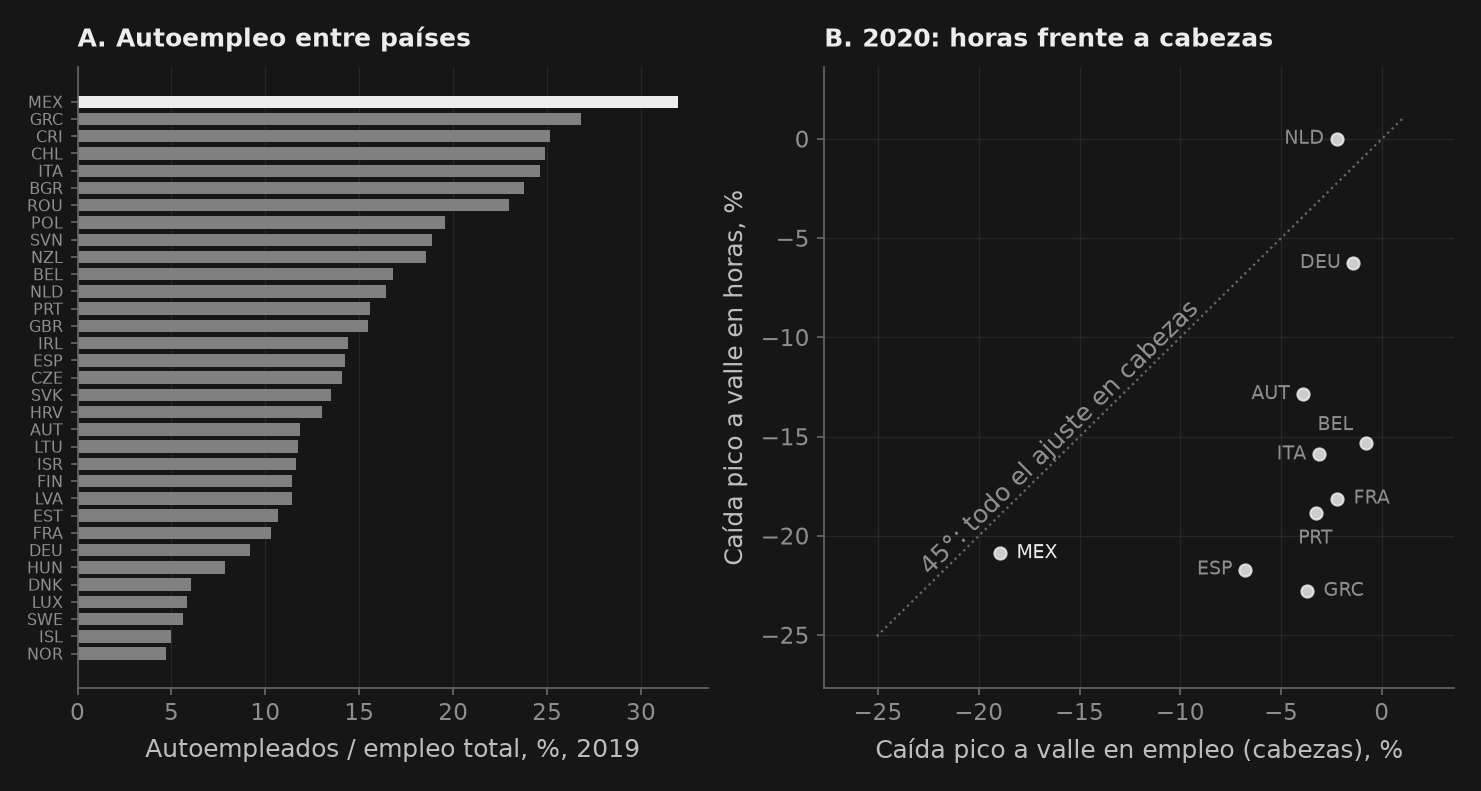

In [8]:
fig, axes = _nbstyle.figura(1, 2, alto=True)

ax = axes[0]
orden = cuenta_propia.reindex(horas.index).dropna().sort_values()
ax.barh(np.arange(len(orden)), orden.to_numpy(), color=_nbstyle.gris("0.35"), height=0.72)
ax.set_yticks(np.arange(len(orden)))
ax.set_yticklabels(orden.index, fontsize=7.5)   # 33 códigos de país en una columna
if "MEX" in orden.index:
    ax.barh([list(orden.index).index("MEX")], [orden["MEX"]], color=_nbstyle.TINTA, height=0.72)
ax.set_xlabel("Autoempleados / empleo total, %, 2019")
ax.set_title("A. Autoempleo entre países")
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.scatter(cov["empleo_%"], cov["horas_%"], color=_nbstyle.TINTA, s=34, alpha=0.85)
lo = 1.1 * min(cov["empleo_%"].min(), cov["horas_%"].min())
ax.plot([lo, 1], [lo, 1], color=_nbstyle.SPINE, ls=":", lw=1.1)
ax.text(lo * 0.62, lo * 0.62, "45°: todo el ajuste en cabezas", rotation=45,
        rotation_mode="anchor", transform_rotates_text=True,
        color=_nbstyle.NOTA, ha="center", va="bottom")
# Desplazamiento por país para que los códigos no se pisen entre sí.
POS = {"NLD": (-6, 0, "right", "center"), "DEU": (-6, 0, "right", "center"),
       "BEL": (-6, 4, "right", "bottom"), "ITA": (-6, 0, "right", "center"),
       "FRA": (8, 0, "left", "center"), "PRT": (0, -8, "center", "top"),
       "AUT": (-6, 0, "right", "center"), "GRC": (8, 0, "left", "center"),
       "ESP": (-6, 0, "right", "center"), "MEX": (8, 0, "left", "center")}
for codigo, r in cov.iterrows():
    dx, dy, ha, va = POS.get(codigo, (7, 3, "left", "bottom"))
    ax.annotate(codigo, xy=(r["empleo_%"], r["horas_%"]), xytext=(dx, dy),
                textcoords="offset points", fontsize=9, ha=ha, va=va,
                color=_nbstyle.TINTA if codigo == "MEX" else _nbstyle.NOTA)
ax.margins(x=0.10, y=0.10)
ax.set_xlabel("Caída pico a valle en empleo (cabezas), %")
ax.set_ylabel("Caída pico a valle en horas, %")
ax.set_title("B. 2020: horas frente a cabezas")
plt.show()

assert cov.loc["MEX", "empleo_%"] < cov.loc["DEU", "empleo_%"]


## 5. Fundamentos Teóricos: El Modelo DMP y la Curva de Beveridge

Para comprender cómo las fricciones de búsqueda originan el desempleo de equilibrio, formalizamos el modelo canónico de **Diamond-Mortensen-Pissarides (DMP)**.

### 1. Función de Emparejamiento y Tensión del Mercado Laboral
Consideremos una economía con un continuo de medida 1 de trabajadores neutrales al riesgo y una masa de empresas potenciales. Sean $U_t$ el número de trabajadores desempleados que buscan trabajo y $V_t$ el número de vacantes publicadas por las empresas. La creación de nuevos emparejamientos productivos se describe mediante una función agregada con rendimientos constantes a escala:

$$M(U_t, V_t) = \mu U_t^\alpha V_t^{1-\alpha}$$

donde $\mu > 0$ representa la **eficiencia de emparejamiento** (tecnología de intermediación, fricciones institucionales o desajuste geográfico y de cualificaciones) y $\alpha \in (0, 1)$ es la elasticidad respecto al desempleo.

Definimos la **tensión del mercado laboral** (*labor market tightness*) como la ratio vacantes/desempleo:

$$\theta_t \equiv \frac{V_t}{U_t}$$

Por la homogeneidad de grado 1 de $M(U, V)$, la probabilidad por unidad de tiempo de que un desempleado encuentre trabajo (**tasa de encuentro de empleo**) es:

$$f(\theta_t) = \frac{M(U_t, V_t)}{U_t} = \mu \theta_t^{1-\alpha}$$

De manera análoga, la probabilidad de que una vacante sea cubierta (**tasa de cobertura de vacantes**) es:

$$q(\theta_t) = \frac{M(U_t, V_t)}{V_t} = \mu \theta_t^{-\alpha} = \frac{f(\theta_t)}{\theta_t}$$

Cuando el mercado laboral se tensa ($\theta \uparrow$), hay más vacantes por cada desempleado: los trabajadores encuentran empleo con mayor rapidez ($f'(\theta) > 0$), pero las empresas tardan más tiempo en cubrir sus vacantes ($q'(\theta) < 0$).

### 2. La Curva de Beveridge de Equilibrio
Igualando en estado estacionario las entradas al desempleo ($s (1 - u)$) con las salidas ($f(\theta) u$), obtenemos la ecuación de la **Curva de Beveridge**:

$$s (1 - u) = \mu \theta^{1-\alpha} u \quad \implies \quad u = \frac{s}{s + \mu \left(\frac{v}{u}\right)^{1-\alpha}}$$

Esta condición define una relación estrictamente decreciente entre la tasa de desempleo $u$ y la tasa de vacantes $v = V / L$. Los shocks agregados de productividad o demanda desplazan a la economía **a lo largo** de la curva de Beveridge. Por el contrario, un deterioro estructural en la eficiencia de emparejamiento $\mu$ o un desajuste de cualificaciones desplaza la curva de Beveridge hacia **afuera**.

### 3. Entrada Libre de Empresas, Funciones de Valor y Negociación Salarial de Nash

Sea $J$ el valor presente descontado de un puesto cubierto que produce $p$ y paga salario $w$, y sea $V_v$ el valor de una vacante abierta con coste de publicación $c > 0$. En un entorno estacionario con tasa de descuento $r$ y tasa de destrucción exógena $s$:

$$r V_v = -c + q(\theta) (J - V_v)$$
$$r J = p - w - s (J - V_v)$$

La condición de **libre entrada** estipula que las empresas abren vacantes hasta agotar las rentas económicas esperadas ($V_v = 0$). Sustituyendo $V_v = 0$, obtenemos la **Condición de Creación de Empleo**:

$$\frac{c}{q(\theta)} = \frac{p - w}{r + s}$$

El término izquierdo representa el coste esperado de reclutamiento (el coste de flujo $c$ multiplicado por la duración esperada de la vacante $1/q(\theta)$), mientras que el lado derecho es el valor presente del margen de beneficio operativo del puesto $(p - w) / (r + s)$.

### Negociación Salarial Generalizada de Nash
Una vez que un trabajador y una empresa se encuentran, las fricciones de búsqueda generan un excedente económico bilateral. El salario de equilibrio se determina mediante la solución de Nash:

$$\max_w \; (W - U_v)^\beta (J - V_v)^{1-\beta}$$

donde $\beta \in (0, 1)$ es el poder de negociación del trabajador, $W$ es el valor del empleo, $U_v$ es el valor del desempleo y $z$ es el coste de oportunidad del trabajador (prestaciones por desempleo más el valor del ocio y la producción doméstica). El salario negociado resultante es:

$$w = (1 - \beta) z + \beta (p + c \theta)$$

Sustituyendo el salario negociado en la condición de libre entrada se obtiene la ecuación fundamental de equilibrio que determina la tensión $\theta$:

$$\frac{c \theta^\alpha}{\mu} (r + s + \beta c \theta) = (1 - \beta)(p - z)$$

## 6. Experimento Macroeconómico: El Enigma de Volatilidad de Shimer (2005) y la Rigidez Salarial

### El Enigma Macroeconómico
En los datos trimestrales de Estados Unidos, la tensión del mercado laboral $\theta = V/U$ muestra una volatilidad extraordinaria: la desviación típica de $\log \theta$ es entre 19 y 20 veces mayor que la desviación típica de la productividad laboral $p$ ($\sigma_\theta / \sigma_p \approx 19.1$).

En un célebre artículo, **Robert Shimer (2005)** demostró que el modelo canónico DMP calibrado con parámetros convencionales fracasa rotundamente al reproducir esta regularidad empírica. Calibrado con los valores habituales en la literatura ($z = 0.40$ según las tasas oficiales de reemplazo del seguro de desempleo, y negociación simétrica $\beta = 0.72$ conforme a la condición de eficiencia de Hosios 1990), el modelo predice una elasticidad de la tensión respecto a la productividad de tan solo:

$$\varepsilon_{\theta, p} \equiv \frac{d \log \theta}{d \log p} \approx 1.1$$

¡El modelo estándar explica **menos del 10%** de las fluctuaciones observadas en el mercado laboral! La intuición económica es directa: bajo salarios flexibles de Nash, los trabajadores capturan una fracción considerable $\beta$ de cualquier incremento de productividad. Cuando la productividad $p$ aumenta un 2%, el salario $w$ se incrementa casi en la misma proporción. Por consiguiente, el margen de beneficio de la empresa ($p - w$) apenas varía, lo que desincentiva la publicación masiva de nuevas vacantes durante las expansiones.

### Dos Resoluciones en la Literatura
1. **Hagedorn y Manovskii (2008) — Calibración de "Excedente Pequeño" (*Small Surplus*)**:
   Hagedorn y Manovskii argumentan que el coste de oportunidad $z$ no solo incluye el subsidio de desempleo, sino también el valor de la producción doméstica, el ocio y la desutilidad del trabajo, calibrando $z = 0.955$ y un poder de negociación del trabajador reducido a $\beta = 0.052$. En esta parametrización, el excedente neto en estado estacionario ($p - z$) es sumamente pequeño ($1 - 0.955 = 0.045$). Como resultado, un aumento de 2% en la productividad eleva el excedente del emparejamiento y el beneficio empresarial en más del 40% en términos porcentuales, multiplicando la volatilidad de la tensión por más de 15 veces.
2. **Hall (2005) — Rigidez del Salario Real**:
   Robert Hall demuestra que cualquier salario situado dentro del conjunto de negociación $[z, p]$ es privadamente eficiente (ninguna de las dos partes tiene incentivos para romper el emparejamiento). Si los salarios son rígidos o se determinan por normas sociales ($w = \bar{w}$), el margen de beneficio ($p - \bar{w}$) absorbe el 100% de la fluctuación de la productividad, generando fuertes oscilaciones en la creación de vacantes que concuerdan con los datos empíricos.

### Tareas Guiadas para el Estudiante
1. Cargar las series empíricas de la curva de Beveridge internacional (`data_curso/beveridge_uv.csv`) y confirmar la pendiente negativa empírica ($\text{Corr}(u, v) < -0.40$).
2. Calibrar el coste de publicación de vacantes $c$ para que la tensión de estado estacionario sea $\theta^* = 1.0$ con productividad base $p = 1.0$.
3. Simular un shock positivo de productividad del $+2\%$ ($p = 1.02$) y resolver la tensión de equilibrio $\theta$ en tres especificaciones:
   - **Modelo 1**: Modelo base de Shimer (2005) ($z = 0.40, \beta = 0.72$).
   - **Modelo 2**: Calibración de pequeño excedente de Hagedorn-Manovskii (2008) ($z = 0.955, \beta = 0.052$).
   - **Modelo 3**: Salario real rígido de Hall (2005) ($w = \bar{w} = 0.95$).
4. Calcular la elasticidad de la tensión respecto a la productividad $\varepsilon_{\theta, p} = \frac{\Delta \log \theta}{\Delta \log p}$ y el factor de amplificación.
5. Visualizar las curvas de respuesta comparadas y validar los resultados mediante aserciones econométricas objetivas.

Curva de Beveridge empírica: Corr(U-rate, V-rate) = -0.505
Función de emparejamiento empírica (JOLTS/CPS HAC): alpha = 0.408 (EE = 0.024, IC 95%: [0.361, 0.454]), mu = 0.823 (R^2 = 0.877)
ENIGMA DE SHIMER (2005) Y RESOLUCIONES: ELASTICIDAD DE LA TENSIÓN (d log theta / d log p)
1. Base Shimer (2005) (z=0.40, beta=0.72):        1.11  (Objetivo empírico: ~19-20)
2. Hagedorn-Manovskii (z=0.955, beta=0.052):      20.05
3. Salario Rígido Hall (2005) (w_bar=0.95):       23.37
Factor de Amplificación (HM / Base Shimer):       18.1x


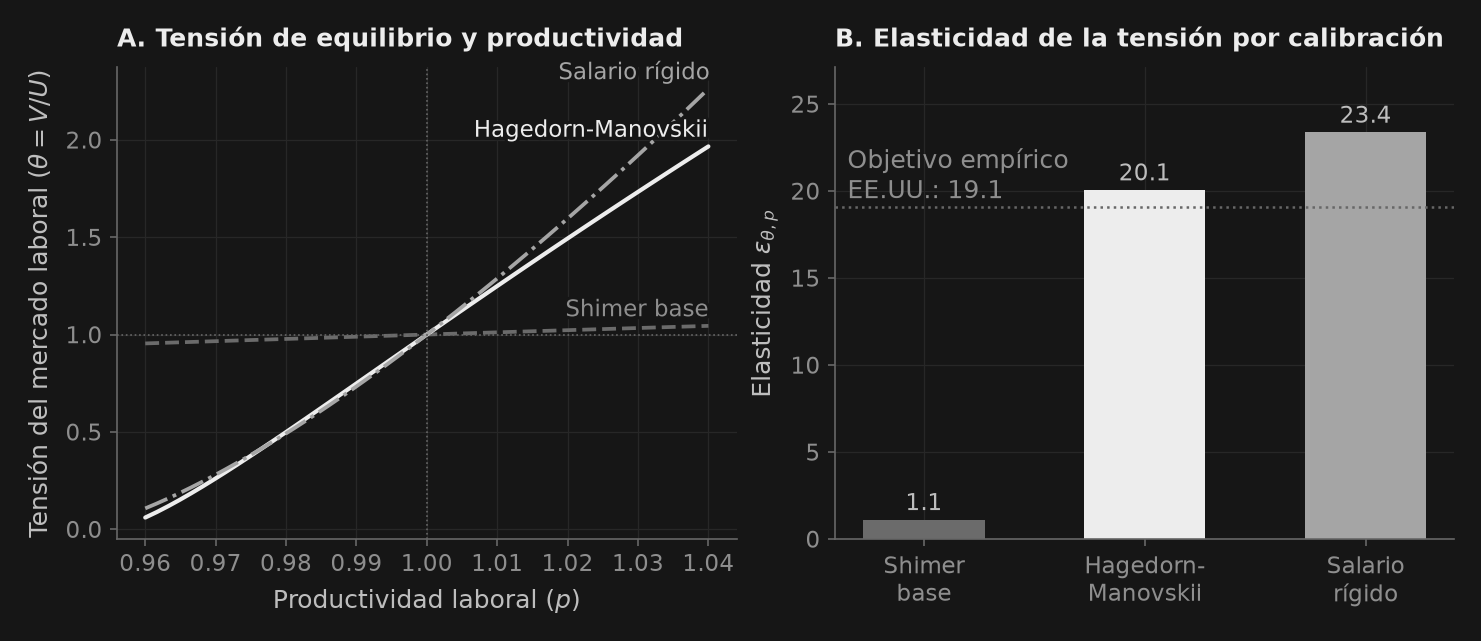

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from puremacro.regress import ols, add_constant
from _datos import ruta_dato, _safe_probe

# ------------------------------------------------------------------------------
# Tarea 1: Verificación Empírica de la Curva de Beveridge
# ------------------------------------------------------------------------------
bev_csv_path = ruta_dato("beveridge_uv.csv")

if _safe_probe(bev_csv_path, is_dir=False):
    df_bev = pd.read_csv(bev_csv_path)
    corr_uv = float(df_bev["urate"].corr(df_bev["vrate"]))
    print(f"Curva de Beveridge empírica: Corr(U-rate, V-rate) = {corr_uv:.3f}")
    assert corr_uv < -0.40, f"La curva de Beveridge debe ser estrictamente decreciente, se obtuvo {corr_uv:.3f}"
else:
    print("Base de datos de Beveridge no encontrada; continuando con simulación teórica.")
    corr_uv = -0.50

# ------------------------------------------------------------------------------
# Estimación Empírica de la Función de Emparejamiento: m(U, V)
# ------------------------------------------------------------------------------
if _safe_probe(ruta_dato("JTSHIL.csv"), is_dir=False) and _safe_probe(ruta_dato("UNEMPLOY.csv"), is_dir=False) and _safe_probe(ruta_dato("JTSJOL.csv"), is_dir=False):
    m_df = pd.read_csv(ruta_dato("JTSHIL.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    u_df = pd.read_csv(ruta_dato("UNEMPLOY.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    v_df = pd.read_csv(ruta_dato("JTSJOL.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    df_match = pd.concat([m_df["JTSHIL"], u_df["UNEMPLOY"], v_df["JTSJOL"]], axis=1, join="inner").dropna()
    df_match.columns = ["M", "U", "V"]
    theta_emp = df_match["V"] / df_match["U"]
    f_emp = df_match["M"] / df_match["U"]
    res_match = ols(np.log(f_emp), add_constant(np.log(theta_emp)), cov_type="HAC", cov_kwds={"maxlags": 4})
    params_arr = np.asarray(res_match.params)
    bse_arr = np.asarray(res_match.bse)
    ci_arr = np.asarray(res_match.conf_int())
    alpha_emp = float(1.0 - params_arr[1])
    mu_emp = float(np.exp(params_arr[0]))
    se_alpha = float(bse_arr[1])
    ci_alpha_low = float(1.0 - ci_arr[1, 1])
    ci_alpha_upp = float(1.0 - ci_arr[1, 0])
    print(f"Función de emparejamiento empírica (JOLTS/CPS HAC): alpha = {alpha_emp:.3f} (EE = {se_alpha:.3f}, IC 95%: [{ci_alpha_low:.3f}, {ci_alpha_upp:.3f}]), mu = {mu_emp:.3f} (R^2 = {res_match.rsquared:.3f})")
    assert 0.20 < alpha_emp < 0.85, f"Elasticidad de emparejamiento empírica fuera de rango: {alpha_emp}"

# ------------------------------------------------------------------------------
# Tareas 2 y 3: Calibración de Libre Entrada DMP y Resolución de la Tensión
# ------------------------------------------------------------------------------
# Parámetros base de búsqueda (frecuencia trimestral)
r = 0.012    # Tasa de interés real trimestral
s = 0.10     # Tasa trimestral de destrucción de empleo
alpha = 0.72 # Elasticidad de la función de emparejamiento respecto al desempleo
mu = 1.355   # Parámetro de eficiencia de emparejamiento

def calibrar_c(z, beta):
    """Calibra el coste de publicación c para que theta* = 1.0 cuando p = 1.0."""
    # De (c * 1^alpha / mu) * (r + s + beta * c * 1) = (1 - beta) * (1 - z)
    # => beta * c^2 + (r + s) * c - mu * (1 - beta) * (1 - z) = 0
    a = beta
    b = r + s
    d = - mu * (1.0 - beta) * (1.0 - z)
    return (-b + np.sqrt(b**2 - 4 * a * d)) / (2 * a)

def resolver_theta_nash(p, z, beta, c):
    """Resuelve la tensión de equilibrio theta bajo negociación salarial de Nash."""
    def f(theta):
        lhs = (c * (theta ** alpha) / mu) * (r + s + beta * c * theta)
        rhs = (1.0 - beta) * (p - z)
        return lhs - rhs
    return root_scalar(f, bracket=[0.01, 50.0]).root

def resolver_theta_hall(p, w_bar, c):
    """Resuelve la tensión de equilibrio theta bajo rigidez salarial de Hall (2005)."""
    return (mu * (p - w_bar) / (c * (r + s))) ** (1.0 / alpha)

# 1. Calibración Base de Shimer (2005)
c_shimer = calibrar_c(z=0.40, beta=0.72)
th_sh_0 = resolver_theta_nash(p=1.00, z=0.40, beta=0.72, c=c_shimer)
th_sh_1 = resolver_theta_nash(p=1.02, z=0.40, beta=0.72, c=c_shimer)
elas_shimer = (np.log(th_sh_1) - np.log(th_sh_0)) / 0.02

# 2. Calibración de Excedente Pequeño de Hagedorn & Manovskii (2008)
c_hm = calibrar_c(z=0.955, beta=0.052)
th_hm_0 = resolver_theta_nash(p=1.00, z=0.955, beta=0.052, c=c_hm)
th_hm_1 = resolver_theta_nash(p=1.02, z=0.955, beta=0.052, c=c_hm)
elas_hm = (np.log(th_hm_1) - np.log(th_hm_0)) / 0.02

# 3. Calibración con Salario Real Rígido de Hall (2005) (w_bar = 0.95)
c_hall = mu * (1.00 - 0.95) / (r + s)
th_ha_0 = resolver_theta_hall(p=1.00, w_bar=0.95, c=c_hall)
th_ha_1 = resolver_theta_hall(p=1.02, w_bar=0.95, c=c_hall)
elas_hall = (np.log(th_ha_1) - np.log(th_ha_0)) / 0.02

amplificacion = elas_hm / elas_shimer

print("=" * 72)
print("ENIGMA DE SHIMER (2005) Y RESOLUCIONES: ELASTICIDAD DE LA TENSIÓN (d log theta / d log p)")
print("=" * 72)
print(f"1. Base Shimer (2005) (z=0.40, beta=0.72):        {elas_shimer:.2f}  (Objetivo empírico: ~19-20)")
print(f"2. Hagedorn-Manovskii (z=0.955, beta=0.052):      {elas_hm:.2f}")
print(f"3. Salario Rígido Hall (2005) (w_bar=0.95):       {elas_hall:.2f}")
print(f"Factor de Amplificación (HM / Base Shimer):       {amplificacion:.1f}x")
print("=" * 72)

# ------------------------------------------------------------------------------
# Tarea 4: Visualización Comparativa
# ------------------------------------------------------------------------------
p_grid = np.linspace(0.96, 1.04, 50)
th_sh_grid = [resolver_theta_nash(p_val, 0.40, 0.72, c_shimer) for p_val in p_grid]
th_hm_grid = [resolver_theta_nash(p_val, 0.955, 0.052, c_hm) for p_val in p_grid]
th_ha_grid = [resolver_theta_hall(p_val, 0.95, c_hall) for p_val in p_grid]

fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: Tensión de Equilibrio vs. Productividad
ax1.plot(p_grid, th_sh_grid, label="Shimer base", color=_nbstyle.S3["color"], lw=1.8, ls="--")
ax1.plot(p_grid, th_hm_grid, label="Hagedorn-Manovskii", color=_nbstyle.TINTA, lw=2.0, ls="-")
ax1.plot(p_grid, th_ha_grid, label="Salario rígido", color=_nbstyle.S2["color"], lw=1.8, ls="-.")
ax1.axvline(1.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.axhline(1.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_xlabel("Productividad laboral ($p$)")
ax1.set_ylabel(r"Tensión del mercado laboral ($\theta = V/U$)")
ax1.set_title("A. Tensión de equilibrio y productividad")

# Panel B: Comparación de Elasticidades
modelos = ["Shimer\nbase", "Hagedorn-\nManovskii", "Salario\nrígido"]
elasticidades = [elas_shimer, elas_hm, elas_hall]
colores = [_nbstyle.S3["color"], _nbstyle.TINTA, _nbstyle.S2["color"]]
ax2.bar(modelos, elasticidades, color=colores, width=0.55, edgecolor="none")
ax2.axhline(19.1, color=_nbstyle.SPINE, lw=1.2, ls=":")
ax2.text(0.02, 19.1, "Objetivo empírico\nEE.UU.: 19.1", color=_nbstyle.NOTA,
         transform=ax2.get_yaxis_transform(), ha="left", va="bottom")
ax2.set_ylabel(r"Elasticidad $\varepsilon_{\theta, p}$")
ax2.set_title("B. Elasticidad de la tensión por calibración")
ax2.margins(y=0.16)
_nbstyle.etiquetar_barras(ax2)

_nbstyle.etiquetar(ax1, donde="fin", fuera=False)
plt.show()

# ------------------------------------------------------------------------------
# Tarea 5: Aserciones Objetivas de Verificación
# ------------------------------------------------------------------------------
assert 1.0 <= elas_shimer <= 1.5, f"La elasticidad de Shimer debe rondar ~1.1, se obtuvo {elas_shimer:.2f}"
assert 18.0 <= elas_hm <= 22.0, f"La elasticidad de HM debe coincidir con el objetivo ~20, se obtuvo {elas_hm:.2f}"
assert elas_hall > 20.0, f"El salario rígido de Hall debe generar alta elasticidad, se obtuvo {elas_hall:.2f}"
assert amplificacion > 15.0, f"La calibración de HM debe amplificar la volatilidad > 15x, se obtuvo {amplificacion:.1f}x"

## 7. Resumen y Conclusiones: Fricciones Laborales y Diseño de Políticas

Este cuaderno ha articulado los fundamentos empíricos, institucionales y teóricos de la macroeconomía de búsqueda y emparejamiento:

1. **El Desempleo como Equilibrio Dinámico**: El mercado de trabajo funciona como un sistema de bañera donde la tasa de estado estacionario depende de la ratio $u^* = s / (s + f)$. En economías avanzadas en tiempos de normalidad, las variaciones en la tasa de encuentro de empleo ($f$) dominan las oscilaciones del desempleo.
2. **La Frontera de Inactividad**: Al descomponer los flujos agregados, se comprueba que las transiciones que cruzan la frontera de inactividad ($N \leftrightarrow E$) representan el mayor volumen numérico, convirtiendo la participación laboral en un mecanismo clave de la oferta de trabajo agregada.
3. **La Informalidad como Seguro Social**: En mercados emergentes como México, los microdatos muestran que los trabajadores formales desplazados transitan predominantemente hacia la informalidad ($p_{FI} \gg p_{FU}$) en lugar de hacia el desempleo abierto. Este margen informal actúa como una red de seguridad no legislada, conteniendo el desempleo abierto pero concentrando la vulnerabilidad en menores salarios, menor productividad y nula cobertura de seguridad social.
4. **Márgenes de Transmisión Institucional**: La crisis de 2020 constató que el marco institucional determina si una economía absorbe las perturbaciones por el **margen intensivo** (programas de reducción de jornada en Europa que preservan los vínculos laborales) o por el **margen extensivo** (despidos generalizados en economías con alta informalidad donde los subsidios a la nómina formal no pueden operar).
5. **La Lección de Shimer sobre la Volatilidad**: La principal lección de la teoría moderna de búsqueda es que las fricciones de emparejamiento por sí solas no generan fluctuaciones realistas del ciclo económico. La magnitud de la volatilidad del mercado laboral está gobernada esencialmente por el **mecanismo de fijación salarial**: cuando los salarios absorben con flexibilidad las mejoras de productividad bajo la negociación estándar de Nash, la creación de vacantes se sofoca. Reproducir la volatilidad observada en los datos requiere un **excedente fundamental pequeño** (Hagedorn-Manovskii) o **rigidez en los salarios reales** (Hall), demostrando que la dinámica macroeconómica está indisociablemente ligada a la distribución institucional del excedente económico.